C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-04-28 07:12:53] [ELAPSED 00:00:00] スクリプト開始
[2026-04-28 07:12:53] [ELAPSED 00:00:00] START TIME = 2026-04-28 07:12:53
[2026-04-28 07:12:53] [ELAPSED 00:00:00] 乱数シード設定: seed=42
[2026-04-28 07:12:53] [ELAPSED 00:00:00] [START] 入力ファイル確認
[2026-04-28 07:12:53] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_features.txt
[2026-04-28 07:12:53] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_classes.txt
[2026-04-28 07:12:53] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_edgelist.txt
[2026-04-28 07:12:53] [ELAPSED 00:00:00] [END] 入力ファイル確認 | phase_elapsed=00:00:00
[2026-04-28 07:12:53] [ELAPSED 00:00:00] [START] 生データ読み込み
[2026-04-28 07:12:53] [ELAPSED 00:00:00] txs_features 読み込み中...
[2026-04-28 07:13:04] [ELAPSED 00:00:10] txs_features 読み込み完了: shape=(203769, 184)
[2026-04-28 07:13:04] [ELAPSED 00:00:10] txs_classes 読み込み中...
[2026-04-28 07:13:04] [ELAPSED 00:00:10] txs_classes 読み込み完了: shape=(203769, 2)
[2026-04-28 07:13:04] [ELAPSED 00:00:10] txs_edgelist 読み込み中...
[2026-04-28 07:13:04] [ELAPSED 00:00:

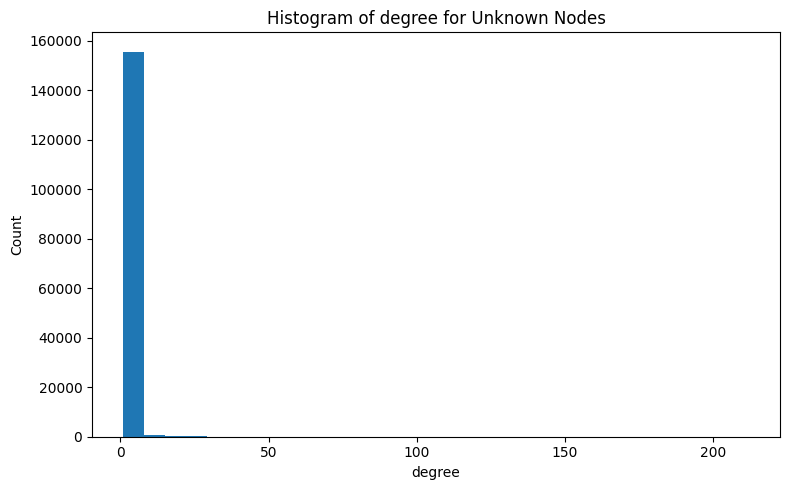

[2026-04-28 07:13:59] [ELAPSED 00:01:05] ヒストグラム描画中: betweenness_centrality


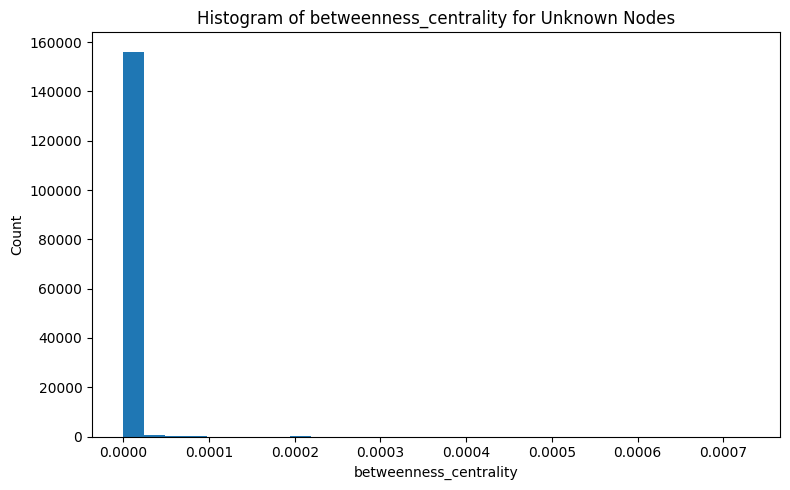

[2026-04-28 07:13:59] [ELAPSED 00:01:05] ヒストグラム描画中: pagerank


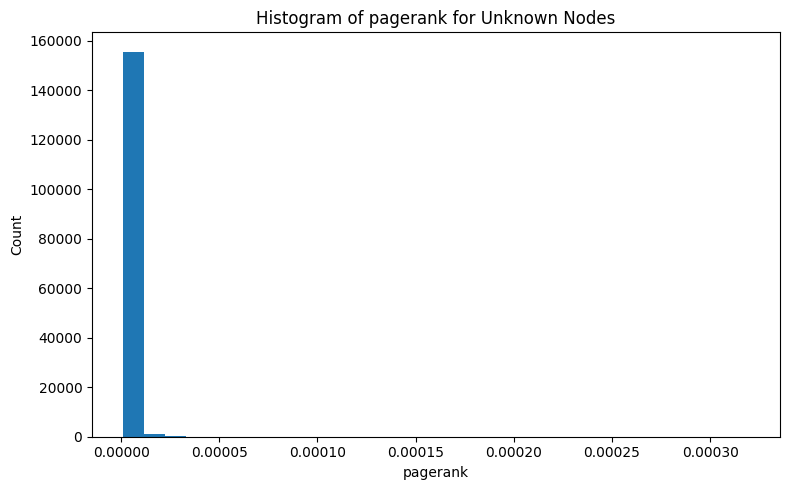

[2026-04-28 07:13:59] [ELAPSED 00:01:06] ヒストグラム描画中: degree_outlier_score


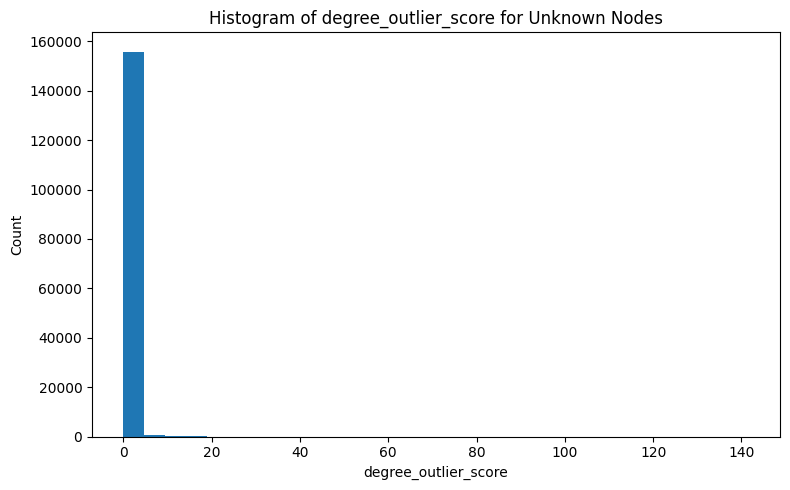

[2026-04-28 07:13:59] [ELAPSED 00:01:06] ヒストグラム描画中: betweenness_centrality_outlier_score


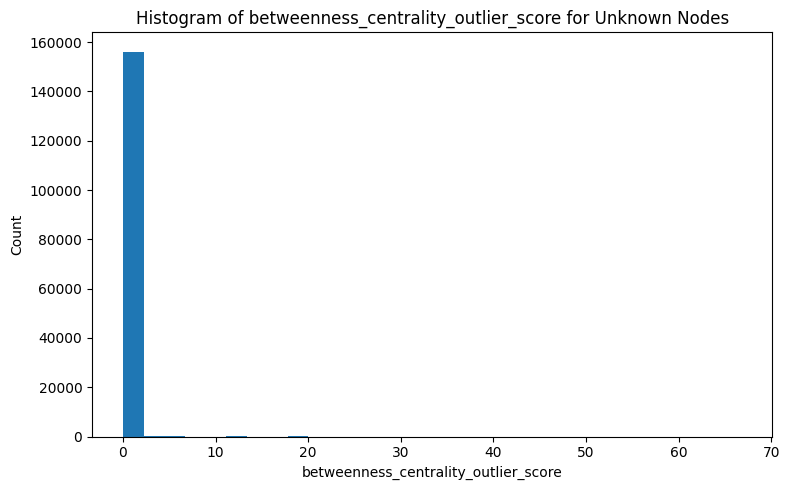

[2026-04-28 07:14:00] [ELAPSED 00:01:06] ヒストグラム描画中: pagerank_outlier_score


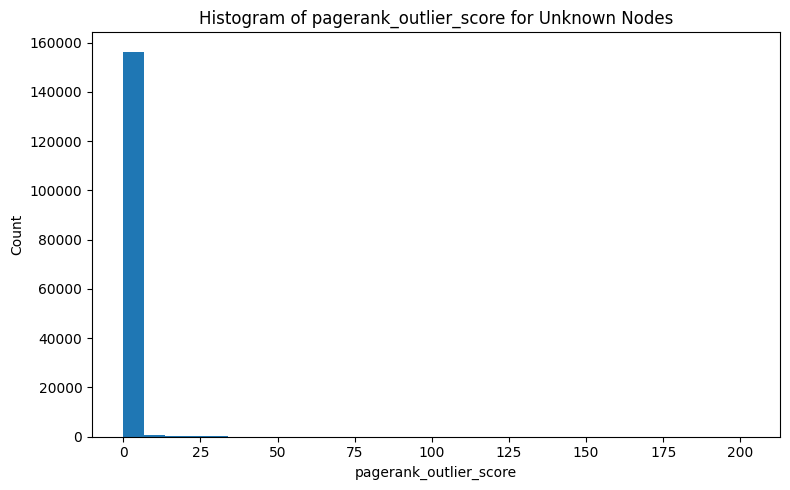

[2026-04-28 07:14:00] [ELAPSED 00:01:06] ヒストグラム描画中: three_type_max_outlier_score


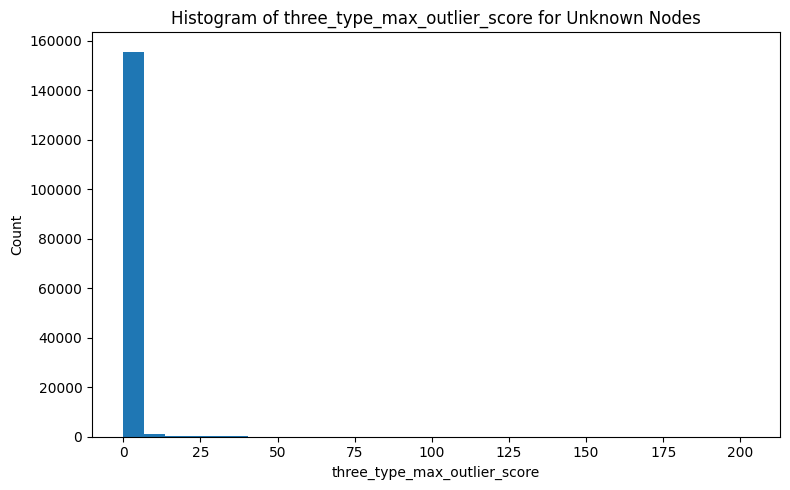

[2026-04-28 07:14:00] [ELAPSED 00:01:07] ヒストグラム描画中: three_type_sum_outlier_score


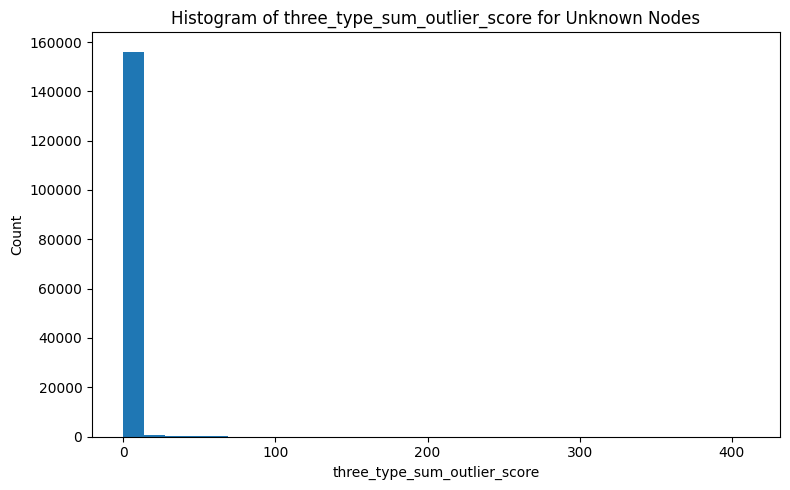

[2026-04-28 07:14:00] [ELAPSED 00:01:07] [END] unknown ノード中心性・外れ値スコア ヒストグラム | phase_elapsed=00:00:02
[2026-04-28 07:14:00] [ELAPSED 00:01:07] [START] time step ごとの unknown 外れ値集計

=== time step ごとの unknown 外れ値集計 ===
 time_step  unknown_count  avg_degree  degree_outlier_count  betweenness_outlier_count  pagerank_outlier_count  any_3type_outlier_count  max_outlier_score  avg_outlier_score  avg_pagerank  avg_betweenness
         1           5733    2.180359                    42                         28                      48                       84         122.640628           0.881481      0.000005     1.876617e-06
         2           3427    2.144733                    48                         14                      21                       70          34.620707           0.918088      0.000005     1.480778e-06
         3           5342    2.526956                   103                        348                      32                      460          29.733716           1.313

In [1]:
# -*- coding: utf-8 -*-

"""
Elliptic++ っぽいトランザクショングラフに対して、
unknown ノード（class=3）を中心性で分析し、
3種類の外れ値ノードを別々にソート表示する完全版。

外れ値タイプ
1) degree が高い外れ値
   → 大量接続ノード

2) betweenness が高い外れ値
   → 資金流路の橋渡しノード

3) pagerank が高い外れ値
   → 重要ノード群に接続する目立つノード
"""

import random
import warnings
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops, to_networkx

warnings.filterwarnings("ignore")


# ==========================
# 設定
# ==========================
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

SEED = 42

INCLUDE_TIME_STEP_AS_FEATURE = False

TOP_K = 10
OUTLIER_TOP_K = 30

ASK_BEFORE_TRAIN = True

# 中心性計算
CALC_BETWEENNESS = True
CALC_PAGERANK = True

# 重いので初期値では False
CALC_CLOSENESS = False
CALC_EIGENVECTOR = False

USE_APPROX_BETWEENNESS = True
BETWEENNESS_K = 100

EIGENVECTOR_MAX_ITER = 1000

# 外れ値判定
OUTLIER_Z_THRESHOLD = 3.5

# ヒストグラム
DRAW_HIST = True
HIST_BINS = 30
FIGSIZE = (8, 5)

# CSV保存
SAVE_CSV = True
OUTPUT_CSV_ALL = "unknown_nodes_centrality_3type_outliers.csv"
OUTPUT_CSV_DEGREE = "unknown_outliers_degree_sorted.csv"
OUTPUT_CSV_BETWEENNESS = "unknown_outliers_betweenness_sorted.csv"
OUTPUT_CSV_PAGERANK = "unknown_outliers_pagerank_sorted.csv"


# ==========================
# ログ
# ==========================
GLOBAL_START_TIME = None


def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def format_seconds(sec: float) -> str:
    sec = int(sec)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def log(msg: str):
    global GLOBAL_START_TIME
    if GLOBAL_START_TIME is None:
        print(f"[{now_str()}] {msg}")
    else:
        elapsed = time.time() - GLOBAL_START_TIME
        print(f"[{now_str()}] [ELAPSED {format_seconds(elapsed)}] {msg}")


class PhaseTimer:
    def __init__(self, name: str):
        self.name = name
        self.start = None

    def __enter__(self):
        self.start = time.time()
        log(f"[START] {self.name}")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed = time.time() - self.start
        log(f"[END] {self.name} | phase_elapsed={format_seconds(elapsed)}")


# ==========================
# 基本関数
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    log(f"乱数シード設定: seed={seed}")


def check_files():
    with PhaseTimer("入力ファイル確認"):
        for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
            if not Path(path).exists():
                raise FileNotFoundError(f"ファイルが見つかりません: {path}")
            log(f"確認OK: {path}")


def confirm_continue():
    while True:
        ans = input("\nこの後の GNN 処理へ進みますか？ (y/n): ").strip().lower()

        if ans in ["y", "yes"]:
            log("ユーザー入力: y -> 続行")
            return True
        elif ans in ["n", "no"]:
            log("ユーザー入力: n -> 終了")
            return False
        else:
            print("y か n を入力してください。")


def normalize_class_value(v):
    """
    1 / illicit  -> 0
    2 / licit    -> 1
    3 / unknown  -> -1
    """
    if pd.isna(v):
        return -1

    s = str(v).strip().lower()

    if s in {"1", "illicit"}:
        return 0
    elif s in {"2", "licit"}:
        return 1
    elif s in {"3", "unknown"}:
        return -1
    else:
        return -1


# ==========================
# データ読み込み
# ==========================
def load_raw_data():
    with PhaseTimer("生データ読み込み"):
        log("txs_features 読み込み中...")
        df_features = pd.read_csv(TXS_FEATURES)
        log(f"txs_features 読み込み完了: shape={df_features.shape}")

        log("txs_classes 読み込み中...")
        df_classes = pd.read_csv(TXS_CLASSES)
        log(f"txs_classes 読み込み完了: shape={df_classes.shape}")

        log("txs_edgelist 読み込み中...")
        df_edges = pd.read_csv(TXS_EDGES)
        log(f"txs_edgelist 読み込み完了: shape={df_edges.shape}")

        print("\n=== Features overview ===")
        print(df_features.head())
        print("missing values total:", int(df_features.isnull().sum().sum()))

        print("\n=== Classes overview ===")
        if "class" in df_classes.columns:
            print(df_classes["class"].value_counts(dropna=False))

        print("\n=== Edges overview ===")
        print(df_edges.head())
        print("duplicate edges:", int(df_edges.duplicated().sum()))

        return df_features, df_classes, df_edges


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame,
    include_time_step_as_feature: bool = False
):
    with PhaseTimer("PyG Data 構築"):
        id_col_feat = df_features.columns[0]
        log(f"ノードID列: {id_col_feat}")

        if "Time step" not in df_features.columns:
            raise ValueError("df_features に 'Time step' 列がありません。")

        time_steps_np = pd.to_numeric(
            df_features["Time step"],
            errors="coerce"
        ).fillna(-1).to_numpy(dtype=np.int64)

        time_steps = torch.tensor(time_steps_np, dtype=torch.long)

        log(
            f"time step 範囲: "
            f"min={int(time_steps.min().item())}, "
            f"max={int(time_steps.max().item())}"
        )

        feature_cols = [c for c in df_features.columns if c != id_col_feat]

        if not include_time_step_as_feature:
            feature_cols = [c for c in feature_cols if c != "Time step"]

        log(f"特徴量列数: {len(feature_cols)}")

        x_df = df_features[feature_cols].copy()
        x_df = x_df.apply(pd.to_numeric, errors="coerce")
        x_df = x_df.replace([np.inf, -np.inf], np.nan)
        x_df = x_df.fillna(0.0)

        x_np = x_df.to_numpy(dtype=np.float32)
        x = torch.tensor(x_np, dtype=torch.float)

        log(f"x shape: {tuple(x.shape)}")
        log(f"x NaN: {torch.isnan(x).any().item()}")
        log(f"x Inf: {torch.isinf(x).any().item()}")

        if "class" not in df_classes.columns:
            raise ValueError("df_classes に 'class' 列がありません。")

        if id_col_feat in df_classes.columns:
            id_col_cls = id_col_feat
        else:
            id_col_cls = df_classes.columns[0]
            log(f"class 側 ID 列として '{id_col_cls}' を使用")

        node_ids = df_features[id_col_feat].astype(int).values
        id2idx = {int(nid): i for i, nid in enumerate(node_ids)}

        log(f"ノード数: {len(node_ids)}")

        cls_series = (
            df_classes
            .set_index(id_col_cls)["class"]
            .reindex(node_ids)
        )

        y_np = cls_series.map(normalize_class_value).to_numpy(dtype=np.int64)
        y = torch.tensor(y_np, dtype=torch.long)

        log("ラベル分布:")
        print(pd.Series(y_np).value_counts(dropna=False).sort_index())

        edge_cols = list(df_edges.columns[:2])
        src_raw = df_edges[edge_cols[0]].values
        dst_raw = df_edges[edge_cols[1]].values

        src_idx = []
        dst_idx = []
        missing_edges = 0

        log(f"元エッジ数: {len(src_raw)}")

        for i, (u, v) in enumerate(zip(src_raw, dst_raw), start=1):
            u = int(u)
            v = int(v)

            if u in id2idx and v in id2idx:
                src_idx.append(id2idx[u])
                dst_idx.append(id2idx[v])
            else:
                missing_edges += 1

            if i % 500000 == 0:
                log(f"エッジ変換進捗: {i}/{len(src_raw)}")

        edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)

        edge_index = to_undirected(edge_index, num_nodes=len(node_ids))
        edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

        log(f"edge_index shape: {tuple(edge_index.shape)}")
        log(f"スキップされたエッジ数: {missing_edges}")

        data = Data(x=x, edge_index=edge_index, y=y)
        data.time_steps = time_steps
        data.node_ids = torch.tensor(node_ids, dtype=torch.long)

        return data


# ==========================
# ロバストZスコア
# ==========================
def robust_z_score(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").fillna(0.0)

    median = s.median()
    mad = (s - median).abs().median()

    if mad == 0:
        std = s.std()
        if std == 0 or pd.isna(std):
            return pd.Series(0.0, index=s.index)
        return (s - s.mean()) / std

    return 0.6745 * (s - median) / mad


# ==========================
# 3タイプ別 外れ値スコア
# ==========================
def add_three_type_outlier_scores(
    df_unknown: pd.DataFrame,
    threshold: float = 3.5
):
    with PhaseTimer("3タイプ別 外れ値スコア計算"):
        score_targets = {
            "degree": "大量接続ノード",
            "betweenness_centrality": "資金流路の橋渡しノード",
            "pagerank": "重要ノード群に接続する目立つノード",
        }

        for col, label in score_targets.items():
            if col not in df_unknown.columns:
                log(f"スキップ: {col} が存在しません")
                continue

            rz_col = f"{col}_rz"
            score_col = f"{col}_outlier_score"
            flag_col = f"{col}_is_outlier"

            df_unknown[rz_col] = robust_z_score(df_unknown[col])
            df_unknown[score_col] = df_unknown[rz_col].abs()
            df_unknown[flag_col] = df_unknown[score_col] >= threshold

            log(
                f"{label}: {col} 外れ値スコア作成完了 "
                f"| outliers={int(df_unknown[flag_col].sum())}"
            )

        existing_score_cols = [
            c for c in [
                "degree_outlier_score",
                "betweenness_centrality_outlier_score",
                "pagerank_outlier_score",
            ]
            if c in df_unknown.columns
        ]

        if existing_score_cols:
            df_unknown["three_type_max_outlier_score"] = (
                df_unknown[existing_score_cols].max(axis=1)
            )
            df_unknown["three_type_sum_outlier_score"] = (
                df_unknown[existing_score_cols].sum(axis=1)
            )

            reason_map = {
                "degree_outlier_score": "大量接続ノード",
                "betweenness_centrality_outlier_score": "資金流路の橋渡しノード",
                "pagerank_outlier_score": "重要ノード群に接続する目立つノード",
            }

            max_cols = df_unknown[existing_score_cols].idxmax(axis=1)
            df_unknown["main_outlier_type"] = max_cols.map(reason_map)

            df_unknown["is_any_3type_outlier"] = (
                df_unknown[existing_score_cols].ge(threshold).any(axis=1)
            )

            log(
                f"3タイプのいずれかで外れ値: "
                f"{int(df_unknown['is_any_3type_outlier'].sum())}"
            )

        return df_unknown


# ==========================
# ソート表示
# ==========================
def print_sorted_outlier_rankings(df: pd.DataFrame, top_k: int = 30):
    with PhaseTimer("3タイプ別 外れ値ランキング表示"):
        base_cols = [
            "node_index",
            "txId",
            "time_step",
            "degree",
        ]

        if "betweenness_centrality" in df.columns:
            base_cols.append("betweenness_centrality")

        if "pagerank" in df.columns:
            base_cols.append("pagerank")

        if "three_type_max_outlier_score" in df.columns:
            base_cols.extend([
                "three_type_max_outlier_score",
                "main_outlier_type",
                "is_any_3type_outlier",
            ])

        # 1) degree 型
        if "degree_outlier_score" in df.columns:
            cols = base_cols + [
                "degree_rz",
                "degree_outlier_score",
                "degree_is_outlier",
            ]

            cols = [c for c in cols if c in df.columns]

            print(f"\n=== 1) 大量接続ノード: degree が高い外れ値トップ{top_k} ===")
            print(
                df.sort_values(
                    ["degree_outlier_score", "degree"],
                    ascending=[False, False]
                )[cols]
                .head(top_k)
                .to_string(index=False)
            )

        # 2) betweenness 型
        if "betweenness_centrality_outlier_score" in df.columns:
            cols = base_cols + [
                "betweenness_centrality_rz",
                "betweenness_centrality_outlier_score",
                "betweenness_centrality_is_outlier",
            ]

            cols = [c for c in cols if c in df.columns]

            print(f"\n=== 2) 資金流路の橋渡しノード: betweenness が高い外れ値トップ{top_k} ===")
            print(
                df.sort_values(
                    [
                        "betweenness_centrality_outlier_score",
                        "betweenness_centrality",
                        "degree",
                    ],
                    ascending=[False, False, False]
                )[cols]
                .head(top_k)
                .to_string(index=False)
            )

        # 3) PageRank 型
        if "pagerank_outlier_score" in df.columns:
            cols = base_cols + [
                "pagerank_rz",
                "pagerank_outlier_score",
                "pagerank_is_outlier",
            ]

            cols = [c for c in cols if c in df.columns]

            print(f"\n=== 3) 重要ノード群に接続する目立つノード: PageRank が高い外れ値トップ{top_k} ===")
            print(
                df.sort_values(
                    ["pagerank_outlier_score", "pagerank", "degree"],
                    ascending=[False, False, False]
                )[cols]
                .head(top_k)
                .to_string(index=False)
            )

        # 総合
        if "three_type_max_outlier_score" in df.columns:
            cols = base_cols + [
                "degree_outlier_score",
                "betweenness_centrality_outlier_score",
                "pagerank_outlier_score",
                "three_type_max_outlier_score",
                "three_type_sum_outlier_score",
                "main_outlier_type",
                "is_any_3type_outlier",
            ]

            cols = [c for c in cols if c in df.columns]

            print(f"\n=== 4) 3タイプ総合: 最大外れ値スコア順トップ{top_k} ===")
            print(
                df.sort_values(
                    ["three_type_max_outlier_score", "three_type_sum_outlier_score"],
                    ascending=[False, False]
                )[cols]
                .head(top_k)
                .to_string(index=False)
            )


# ==========================
# unknown ノード分析
# ==========================
def analyze_unknown_nodes_3type_outliers(
    data: Data,
    top_k: int = 10,
    outlier_top_k: int = 30
):
    with PhaseTimer("unknown ノード 3タイプ外れ値分析"):
        log("NetworkX グラフへ変換中...")
        G = to_networkx(data.cpu(), to_undirected=True)

        log(
            f"NetworkX グラフ変換完了: "
            f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}"
        )

        log("自己ループ削除中...")
        G.remove_edges_from(nx.selfloop_edges(G))
        log(
            f"自己ループ削除後: "
            f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}"
        )

        y = data.y.cpu().numpy()
        node_ids = data.node_ids.cpu().numpy()
        time_steps = data.time_steps.cpu().numpy()

        unknown_nodes = np.where(y == -1)[0]
        n_unknown = len(unknown_nodes)

        log(f"unknown ノード数: {n_unknown}")

        if n_unknown == 0:
            print("unknown ノードは存在しません。")
            return pd.DataFrame(), G

        log("次数を取得中...")
        degree_dict = dict(G.degree())
        log("次数取得完了")

        log("次数中心性を計算中...")
        degree_cent = nx.degree_centrality(G)
        log("次数中心性 計算完了")

        closeness_cent = None
        if CALC_CLOSENESS:
            log("近接中心性を計算中... 大規模グラフでは非常に重い可能性があります")
            closeness_cent = nx.closeness_centrality(G)
            log("近接中心性 計算完了")

        betweenness_cent = None
        if CALC_BETWEENNESS:
            if USE_APPROX_BETWEENNESS:
                log(f"媒介中心性を近似計算中... k={BETWEENNESS_K}")
                betweenness_cent = nx.betweenness_centrality(
                    G,
                    k=BETWEENNESS_K,
                    seed=SEED
                )
                log("媒介中心性 近似計算完了")
            else:
                log("媒介中心性を厳密計算中... 非常に重い可能性があります")
                betweenness_cent = nx.betweenness_centrality(G)
                log("媒介中心性 厳密計算完了")

        pagerank_cent = None
        if CALC_PAGERANK:
            log("PageRank を計算中...")
            pagerank_cent = nx.pagerank(G)
            log("PageRank 計算完了")

        eigenvector_cent = None
        if CALC_EIGENVECTOR:
            log("固有ベクトル中心性を計算中...")
            try:
                eigenvector_cent = nx.eigenvector_centrality(
                    G,
                    max_iter=EIGENVECTOR_MAX_ITER
                )
                log("固有ベクトル中心性 計算完了")
            except Exception as e:
                log(f"固有ベクトル中心性が収束しませんでした: {e}")
                eigenvector_cent = {n: 0.0 for n in G.nodes()}

        rows = []

        log("unknown ノードごとの中心性テーブル作成中...")

        for i, n in enumerate(unknown_nodes, start=1):
            row = {
                "node_index": int(n),
                "txId": int(node_ids[n]),
                "time_step": int(time_steps[n]),
                "degree": int(degree_dict.get(n, 0)),
                "degree_centrality": float(degree_cent.get(n, 0.0)),
            }

            if closeness_cent is not None:
                row["closeness_centrality"] = float(closeness_cent.get(n, 0.0))

            if betweenness_cent is not None:
                row["betweenness_centrality"] = float(betweenness_cent.get(n, 0.0))

            if pagerank_cent is not None:
                row["pagerank"] = float(pagerank_cent.get(n, 0.0))

            if eigenvector_cent is not None:
                row["eigenvector_centrality"] = float(eigenvector_cent.get(n, 0.0))

            rows.append(row)

            if i % 10000 == 0:
                log(f"unknown ノード集計進捗: {i}/{n_unknown}")

        df_unknown = pd.DataFrame(rows)

        log(f"unknown 中心性テーブル完成: shape={df_unknown.shape}")

        df_unknown = add_three_type_outlier_scores(
            df_unknown=df_unknown,
            threshold=OUTLIER_Z_THRESHOLD
        )

        print_sorted_outlier_rankings(
            df_unknown,
            top_k=outlier_top_k
        )

        print("\n=== unknown ノード中心性・外れ値スコアの基本統計 ===")
        stat_cols = [
            c for c in [
                "degree",
                "degree_centrality",
                "betweenness_centrality",
                "pagerank",
                "degree_outlier_score",
                "betweenness_centrality_outlier_score",
                "pagerank_outlier_score",
                "three_type_max_outlier_score",
                "three_type_sum_outlier_score",
            ]
            if c in df_unknown.columns
        ]

        print(df_unknown[stat_cols].describe())

        return df_unknown, G


# ==========================
# ヒストグラム
# ==========================
def plot_unknown_centrality_histograms(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("ヒストグラム描画スキップ: unknown ノードなし")
        return

    with PhaseTimer("unknown ノード中心性・外れ値スコア ヒストグラム"):
        cols = [
            c for c in [
                "degree",
                "betweenness_centrality",
                "pagerank",
                "degree_outlier_score",
                "betweenness_centrality_outlier_score",
                "pagerank_outlier_score",
                "three_type_max_outlier_score",
                "three_type_sum_outlier_score",
            ]
            if c in df_unknown.columns
        ]

        for col in cols:
            log(f"ヒストグラム描画中: {col}")
            plt.figure(figsize=FIGSIZE)
            plt.hist(df_unknown[col], bins=HIST_BINS)
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.title(f"Histogram of {col} for Unknown Nodes")
            plt.tight_layout()
            plt.show()


# ==========================
# time step 集計
# ==========================
def summarize_unknown_by_time_step(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("time step 集計スキップ: unknown ノードなし")
        return

    with PhaseTimer("time step ごとの unknown 外れ値集計"):
        agg_dict = {
            "unknown_count": ("node_index", "count"),
            "avg_degree": ("degree", "mean"),
        }

        if "degree_is_outlier" in df_unknown.columns:
            agg_dict["degree_outlier_count"] = ("degree_is_outlier", "sum")

        if "betweenness_centrality_is_outlier" in df_unknown.columns:
            agg_dict["betweenness_outlier_count"] = (
                "betweenness_centrality_is_outlier",
                "sum"
            )

        if "pagerank_is_outlier" in df_unknown.columns:
            agg_dict["pagerank_outlier_count"] = ("pagerank_is_outlier", "sum")

        if "is_any_3type_outlier" in df_unknown.columns:
            agg_dict["any_3type_outlier_count"] = ("is_any_3type_outlier", "sum")

        if "three_type_max_outlier_score" in df_unknown.columns:
            agg_dict["max_outlier_score"] = ("three_type_max_outlier_score", "max")
            agg_dict["avg_outlier_score"] = ("three_type_max_outlier_score", "mean")

        if "pagerank" in df_unknown.columns:
            agg_dict["avg_pagerank"] = ("pagerank", "mean")

        if "betweenness_centrality" in df_unknown.columns:
            agg_dict["avg_betweenness"] = ("betweenness_centrality", "mean")

        summary = (
            df_unknown.groupby("time_step")
            .agg(**agg_dict)
            .reset_index()
            .sort_values("time_step")
        )

        print("\n=== time step ごとの unknown 外れ値集計 ===")
        print(summary.to_string(index=False))


# ==========================
# CSV保存
# ==========================
def save_outputs(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("CSV保存スキップ: データなし")
        return

    with PhaseTimer("CSV保存"):
        df_unknown_sorted = df_unknown.sort_values(
            "three_type_max_outlier_score"
            if "three_type_max_outlier_score" in df_unknown.columns
            else "degree",
            ascending=False
        )

        df_unknown_sorted.to_csv(
            OUTPUT_CSV_ALL,
            index=False,
            encoding="utf-8-sig"
        )

        log(f"全unknownノードCSV保存: {OUTPUT_CSV_ALL}")

        if "degree_outlier_score" in df_unknown.columns:
            df_degree = df_unknown.sort_values(
                ["degree_outlier_score", "degree"],
                ascending=[False, False]
            )
            df_degree.to_csv(
                OUTPUT_CSV_DEGREE,
                index=False,
                encoding="utf-8-sig"
            )
            log(f"degree外れ値CSV保存: {OUTPUT_CSV_DEGREE}")

        if "betweenness_centrality_outlier_score" in df_unknown.columns:
            df_bet = df_unknown.sort_values(
                [
                    "betweenness_centrality_outlier_score",
                    "betweenness_centrality",
                    "degree",
                ],
                ascending=[False, False, False]
            )
            df_bet.to_csv(
                OUTPUT_CSV_BETWEENNESS,
                index=False,
                encoding="utf-8-sig"
            )
            log(f"betweenness外れ値CSV保存: {OUTPUT_CSV_BETWEENNESS}")

        if "pagerank_outlier_score" in df_unknown.columns:
            df_pr = df_unknown.sort_values(
                ["pagerank_outlier_score", "pagerank", "degree"],
                ascending=[False, False, False]
            )
            df_pr.to_csv(
                OUTPUT_CSV_PAGERANK,
                index=False,
                encoding="utf-8-sig"
            )
            log(f"pagerank外れ値CSV保存: {OUTPUT_CSV_PAGERANK}")


# ==========================
# main
# ==========================
def main():
    global GLOBAL_START_TIME
    GLOBAL_START_TIME = time.time()

    log("スクリプト開始")
    log(f"START TIME = {now_str()}")

    set_seed(SEED)
    check_files()

    df_features, df_classes, df_edges = load_raw_data()

    data = build_pyg_data(
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges,
        include_time_step_as_feature=INCLUDE_TIME_STEP_AS_FEATURE
    )

    df_unknown, G = analyze_unknown_nodes_3type_outliers(
        data=data,
        top_k=TOP_K,
        outlier_top_k=OUTLIER_TOP_K
    )

    if SAVE_CSV:
        save_outputs(df_unknown)

    if DRAW_HIST:
        plot_unknown_centrality_histograms(df_unknown)

    summarize_unknown_by_time_step(df_unknown)

    if ASK_BEFORE_TRAIN:
        if not confirm_continue():
            total_elapsed = time.time() - GLOBAL_START_TIME
            log(f"ここで終了します。総経過時間={format_seconds(total_elapsed)}")
            return

    log("この先に GNN 学習処理を接続できます。")

    total_elapsed = time.time() - GLOBAL_START_TIME
    log(f"Done. 総経過時間={format_seconds(total_elapsed)}")


if __name__ == "__main__":
    main()